This file below is adapted from a checkpoint examination done during my traning bootcamp with the WILD CODE SCHOOL.

This file below is adapted from a checkpoint examination done during my training bootcamp with the WILD CODE SCHOOL.
<p>Notebook highlighting work done with Python and using Machine Learming techniques
<li>Python
<li>Machine Learning

# LOADING THE DATA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


url = "https://raw.githubusercontent.com/murpi/wilddata/master/quests/spotify.zip"
df_music = pd.read_csv(url)
df_music

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.61100,0.389,99373,0.910,0.000000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.24600,0.590,137373,0.737,0.000000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.95200,0.663,170267,0.131,0.000000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.70300,0.240,152427,0.326,0.000000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.95000,0.331,82625,0.225,0.123000,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232720,Soul,Slave,Son Of Slide,2XGLdVl7lGeq8ksM6Al7jT,39,0.00384,0.687,326240,0.714,0.544000,D,0.0845,-10.626,Major,0.0316,115.542,4/4,0.962
232721,Soul,Jr Thomas & The Volcanos,Burning Fire,1qWZdkBl4UVPj9lK6HuuFM,38,0.03290,0.785,282447,0.683,0.000880,E,0.2370,-6.944,Minor,0.0337,113.830,4/4,0.969
232722,Soul,Muddy Waters,(I'm Your) Hoochie Coochie Man,2ziWXUmQLrXTiYjCg2fZ2t,47,0.90100,0.517,166960,0.419,0.000000,D,0.0945,-8.282,Major,0.1480,84.135,4/4,0.813
232723,Soul,R.LUM.R,With My Words,6EFsue2YbIG4Qkq8Zr9Rir,44,0.26200,0.745,222442,0.704,0.000000,A,0.3330,-7.137,Major,0.1460,100.031,4/4,0.489


# Data exploration

## Introduction

In [5]:
# First rows of the dataset : 

df_music.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


Describing the dataset including all types of columns (i.e. numerical and the others) and comment the column popularity.

In [20]:
# Giving info about the DB: number of entries, column name and type, DB size: 

df_music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [21]:
# The column "popularity" is set as an integer in the DB. This is a categorical column 
# Describing (ie giving descriptives stats for all the numerical columns):

df_music.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


Please check the presence / absence of missing values in each column and comment your result.

In [ ]:
df_music.isna().sum()

genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

In [9]:
# There are no missing values in the dataset. No work to be done on that side :)

## Some insights about the artists

Give the number of tracks for each artist. The result will be sorted by descending order for a better readability.

*You can use `groupby`, `crosstab` or `pivot_table` to solve these questions.*


In [55]:
# Your code here : 

artist_tracks = pd.pivot_table(df_music, index = ['artist_name']
                               , aggfunc = 'count'
                               
                               , values = ['track_id'], dropna = True )

In [56]:
artist_tracks = artist_tracks.sort_values('track_id', ascending = False)

In [60]:
# Renaming the columns for better readability
artist_tracks = artist_tracks.rename(columns = {'track_id' : 'Number of tracks'})\
    .rename_axis('Artist name')

In [61]:
artist_tracks.head()

,Number of tracks
Artist name,
Giuseppe Verdi,1394
Giacomo Puccini,1137
Kimbo Children's Music,971
Nobuo Uematsu,825
Richard Wagner,804



Give the mean of popularity for each artist. The result will be sorted by descending order for a better readability.
In addition, who are the 3 most popular artists ?

In [15]:
# Your code here : 

artist_popularity= df_music.groupby(by= 'artist_name')['popularity'].mean()

artist_popularity.sort_values(ascending = False)

artist_name
Pedro Capó              87.0
Mario Bautista          85.0
Mau y Ricky             83.0
Kris Kross Amsterdam    82.0
Ninho                   82.0
                        ... 
Brent Holmes             0.0
The Wayfarers            0.0
Nursery Rhymes Club      0.0
Renee & Jeremy           0.0
Steve Stevens            0.0
Name: popularity, Length: 14564, dtype: float64

## What about Queen?
Give the track names of Queen.

In [62]:
# Your code here : 

queen_mask = (df_music['artist_name'] =='Queen')

# returning the corresponding rows (saving into df for later use):
queen_df = df_music.loc[queen_mask]
queen_df

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
152988,Rock,Queen,We Are The Champions,4kzvAGJirpZ9ethvKZdJtg,50,0.23000,0.460,180667,0.4820,0.000000,A#,0.1010,-7.413,Major,0.0285,94.975,3/4,0.2020
153284,Rock,Queen,"Get Down, Make Love - Remastered 2011",1DdC1R2eDWg3Xq9RPSX4h2,50,0.42300,0.441,230120,0.7230,0.000000,G#,0.3600,-4.746,Major,0.2570,143.711,4/4,0.4540
153622,Rock,Queen,Sheer Heart Attack - Remastered 2011,5AHQ3hXjXQzmtCT5iEkh2f,50,0.00867,0.359,207600,0.9310,0.001890,A#,0.3590,-4.564,Major,0.1080,91.499,4/4,0.4180
153734,Rock,Queen,Seaside Rendezvous - Remastered 2011,5w49nWH532c39tuJ3kthEm,49,0.40800,0.450,134133,0.7060,0.000000,C,0.2920,-5.462,Major,0.1130,167.906,4/4,0.7640
154806,Rock,Queen,Sleeping On The Sidewalk - Remastered 2011,6T4mvqvMIwa0S6EH84QAAJ,48,0.48400,0.615,186080,0.7700,0.000168,E,0.3250,-7.674,Major,0.0274,129.734,4/4,0.6450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225833,Rock,Queen,Fat Bottomed Girls,39sH8Fl415P7O8GRP1Td6Z,51,0.04000,0.252,255533,0.6570,0.000016,D,0.3270,-10.102,Major,0.0581,178.010,4/4,0.3980
225906,Rock,Queen,"All Dead, All Dead - Remastered 2011",1YBkXyn1nlp2SdCdsNkGtS,51,0.79000,0.456,189587,0.0799,0.000108,F,0.1100,-14.775,Major,0.0344,88.914,4/4,0.2530
226106,Rock,Queen,Somebody To Love,3CCxL8R4wxfrGKqAmprgQi,51,0.11600,0.491,295960,0.5810,0.000000,G#,0.1250,-10.693,Major,0.0542,110.179,3/4,0.4220
226296,Rock,Queen,No-One But You (Only The Good Die Young),4pRnWYreOtP4jXdvhzRvdA,51,0.57300,0.496,251333,0.4000,0.000000,C,0.0909,-8.272,Minor,0.0301,119.395,3/4,0.0932


What are the mean popularity of all songs from the Queen band?

What are their 3 most popular songs?

In [63]:
# Your code here : 

print('The mean popularity of the british rock band Queen is', round(queen_df.popularity.mean(),2))

The mean popularity of the british rock band Queen is 58.79


In [64]:
# 3 Most popular songs:

queen_df.nlargest(3,'popularity')

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
166058,Rock,Queen,Bohemian Rhapsody - Remastered 2011,7tFiyTwD0nx5a1eklYtX2J,82,0.2540,0.397,354320,0.396,0.000000,D#,0.268,-9.910,Major,0.0500,142.913,4/4,0.227
166059,Rock,Queen,Don't Stop Me Now - Remastered,7hQJA50XrCWABAu5v6QZ4i,81,0.0488,0.559,209413,0.855,0.000681,F,0.680,-5.077,Major,0.1860,156.311,4/4,0.605
166067,Rock,Queen,Under Pressure - Remastered,11IzgLRXV7Cgek3tEgGgjw,77,0.4440,0.667,248440,0.705,0.000000,D,0.107,-7.657,Major,0.0488,113.808,4/4,0.506


## Transform (apply ?)
Create a new column `nb_words`, with the number of words in each title (track names). It's up to you to choose if punctuation is a word or not.

In [81]:
# we only consider the name without the labum name, so performing a calculationtrack name length

df_music['nb_words'] = df_music['track_name'].str.split("-", n=1, expand = True)[0].str.len()
  

In [82]:
# Your code here : 
df_music.head()


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,nb_words
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814,27.0
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816,32.0
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368,30.0
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227,3.0
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390,9.0


## Pivot table
Let's do a pivot table with `genre` in rows, `mode` in columns and number of songs in values. 

Which genre-mode duo contains the most songs?

In [83]:
# Your code here : 

genre_music = pd.pivot_table(df_music, index = ['genre', 'mode']
                               , aggfunc = 'count'
                               , values = ['track_id'], dropna = True )

genre_music.sort_values(by = 'track_id', ascending = False).nlargest(10, 'track_id')

,,track_id
genre,mode,
Country,Major,7583
Folk,Major,7279
Rock,Major,6878
World,Major,6823
Comedy,Major,6699
Ska,Major,6580
Indie,Major,6570
Opera,Major,6418
Blues,Major,6415


In [ ]:
# Country / Major is the genre - mode duo who contains the most songs.

# Dataviz - Matplotlib, Seaborn

## Remember, each chart must have :
- beautiful colors
- title
- readable axis ticks
- legend

## Display a correlation heatmap
Color scale has to be **centered on 0-value**, in order to distinguish negative and positive values. Please choose a beautiful **diverging palette**, and remember to **display a title**.


In [ ]:
# import libraires

import seaborn as sns
import matplotlib.pyplot as plt

### SEABORN

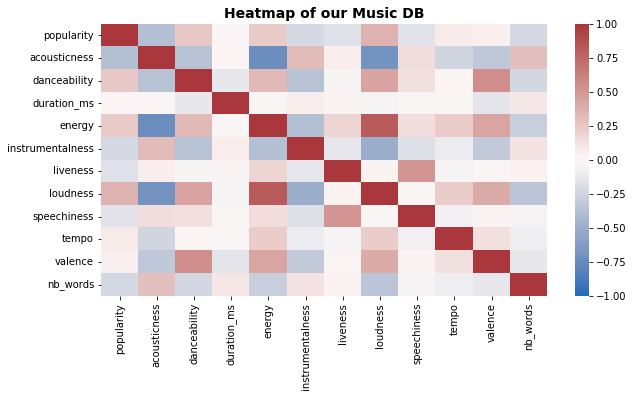

In [ ]:
f, ax = plt.subplots(figsize=(10,5))

# Heatmap
sns.heatmap(df_music.corr(), 
            cmap = sns.color_palette('vlag', as_cmap=True), 
            center = 0, vmin = -1,
            yticklabels = 1   # met un tick toutes les colonnes
            ) 
plt.title('Heatmap of our Music DB', weight = 'bold', fontsize = 14)

plt.show()

Some columns seem to have strong (negative) correlations between them. 
- Which ones? 
- What does it mean?

In [ ]:
# Your answers here :

# Acousticness have strong negative correlations with energy and loudness.
# Acousticness describes how acoustic a song is 
#(A score of 1.0 means the song is most likely to be an acoustic one).
# An acoustic song is very likely to be quieter 
# (opposite of loud ie negative loudness) and less energetic (measure of intensity and activity)



## Find the correlation coefficient between Energy and Acousticness

In [ ]:
# Your code here :

energy_acousticness = df_music[['energy','acousticness']]
energy_acousticness.corr()

,energy,acousticness
energy,1.000000,-0.725576
acousticness,-0.725576,1.000000


In [ ]:
# The correlation coefficient between Energy and Acousticness is of -0.72

## Pairplot
Only for genres Opera and Reggaeton, display a pairplot with different colors for genres (so you'll have 2 colors).

*If the dataset is too big, you can use sampling methods.*

In [ ]:
# Creating a mask for selecting only opera and reggaeton:

genre_opera = df_music['genre'] == 'Opera'
genre_reggaeton =  df_music['genre'] == 'Reggaeton'

# applying our mask + sampling the DF to 2000 entries:
op_reggaeton_df = df_music.loc[genre_opera | genre_reggaeton].sample(2000)
op_reggaeton_df.shape

(2000, 19)

In [ ]:
op_reggaeton_df.columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence', 'nb_words'],
      dtype='object')

In [ ]:
op_reggaeton_df.dtypes

genre                object
artist_name          object
track_name           object
track_id             object
popularity            int64
acousticness        float64
danceability        float64
duration_ms           int64
energy              float64
instrumentalness    float64
key                  object
liveness            float64
loudness            float64
mode                 object
speechiness         float64
tempo               float64
time_signature       object
valence             float64
nb_words              int64
dtype: object

In [13]:
df_music.select_dtypes(['int64', 'float64']).columns

Index(['popularity', 'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'valence'],
      dtype='object')

In [ ]:
# Pairplot using our new df w 2 genres,  2000 rows for selected columns (numericals)

g = sns.pairplot(op_reggaeton_df
            , x_vars = ['popularity','acousticness', 'danceability', 'duration_ms'
            , 'energy','instrumentalness', 'liveness', 'loudness', 
      'speechiness', 'tempo', 'valence', 'nb_words']
            , y_vars = ['popularity','acousticness', 'danceability', 'duration_ms'
            , 'energy','instrumentalness', 'liveness', 'loudness', 
      'speechiness', 'tempo', 'valence', 'nb_words']
           , hue = 'genre'
            )
g.fig.suptitle('Pairplots of our Music DB'
              , weight = 'bold', fontsize = 14
             , y = 1.08
              ) # y= some height>1 
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Scatterplot
Draw a scatterplot on the columns of your choice:
- Include only genres Opera and Reggaeton
- Each genre has its own color
- Please choose beautiful colors, and remember to display a title.

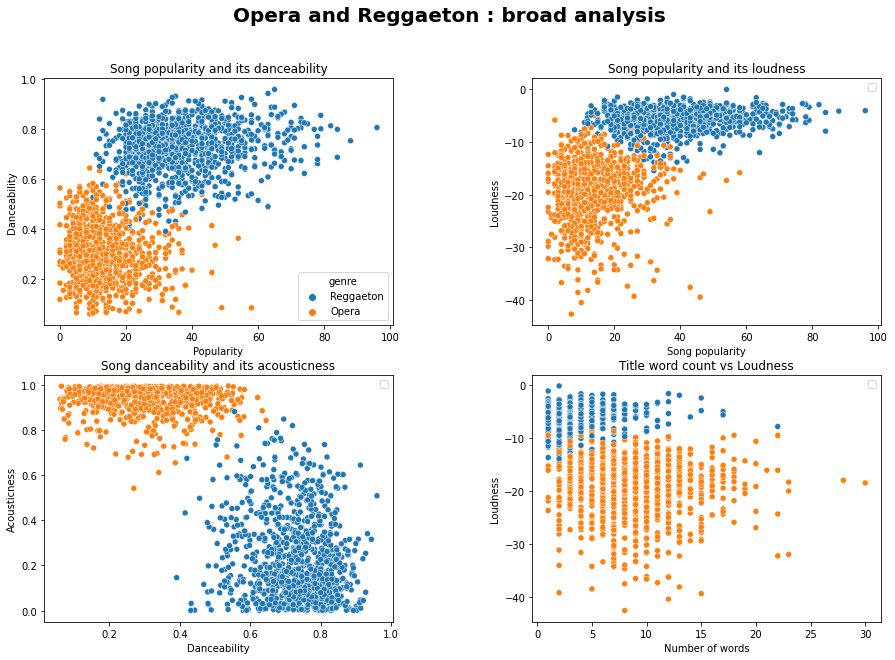

In [ ]:
# Your code here :

# Dessin de la figure
fig, ax = plt.subplots(nrows = 2 , ncols = 2, figsize=(15,10))


# interesting variables : popularity, danceability, loudness
#duration / energy

# Graph 1 - Variables   POPULARITY / DANCEABILITY
ax1 = plt.subplot(221)
sns.scatterplot(data = op_reggaeton_df
        , x = 'popularity'
        , y =  'danceability'
        , hue = 'genre'
        )

ax1.set_title('Song popularity and its danceability')
ax1.set_xlabel('Popularity')
ax1.set_ylabel('Danceability')

# Graph 2 -  POPULARITY / LOUDNESS
ax2 = plt.subplot(222)

sns.scatterplot(data = op_reggaeton_df
        , x = 'popularity'
        , y = 'loudness'
        , hue = 'genre'
          )

ax2.set_title('Song popularity and its loudness')
ax2.set_xlabel('Song popularity')
ax2.set_ylabel('Loudness')
ax2.legend('')

# Graph 3 - DANCEABILITY / ACOUSCTICNESS
ax3 = plt.subplot(223)

sns.scatterplot(data = op_reggaeton_df
        , x = 'danceability'
        , y = 'acousticness'
        , hue = 'genre'
                )

ax3.set_title('Song danceability and its acousticness')
ax3.set_xlabel('Danceability')
ax3.set_ylabel('Acousticness')
ax3.legend('')

# Graph 4 -  NB_WORDS / LOUDNESS
ax4 = plt.subplot(224)

sns.scatterplot(data = op_reggaeton_df
        , x = 'nb_words'
        , y = 'loudness'
        , hue = 'genre'
                )

ax4.set_title('Title word count vs Loudness')
ax4.set_xlabel('Number of words')
ax4.set_ylabel('Loudness')
ax4.legend('')

fig.suptitle ('Opera and Reggaeton : broad analysis', weight = 'bold' , fontsize = 20)
plt.subplots_adjust(wspace=0.4)

plt.show()

## Boxplot
Draw on the same figure 2 boxplots : 1 by genre.
- Boxplots have to be in vertical
- Filter only on genres Opera and Reggaeton
- Your boxplots represent danceability

Your chart must be similar to this one (without the red arrow)

![boxplot](https://raw.githubusercontent.com/murpi/wilddata/master/checkpoint2_boxplot.png)

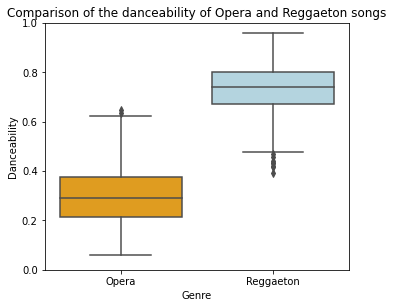

In [ ]:
# Your code here :

fig, ax = plt.subplots( figsize=(12,10))
ax1 = plt.subplot(222)
sns.boxplot(data = op_reggaeton_df
                  , x = 'genre'
                  , y = 'danceability'
                  , order = ('Opera', 'Reggaeton')
                  , palette =['orange', 'lightblue'])
ax1.set_ylabel('Danceability')
ax1.set_xlabel('Genre')
ax1.set_ylim(0,1)
plt.title('Comparison of the danceability of Opera and Reggaeton songs')

plt.show()

In [ ]:
##Attention car le graphe prend uniquement le sample de 2000.

How do we read it ?
- What does the horizontal line near the red arrow represent? What does it mean?

In [ ]:
# Your answer here :
# This boxplot represents the distribution of the values for the variable Danceability for the 2 genres. 

# The line represents the 3rd quartile ie at least 75% of the Reggaeton songs dancebility are under that line.

## Histogram
Draw a histogram for the distribution of "energy", only for the genre 'Country'

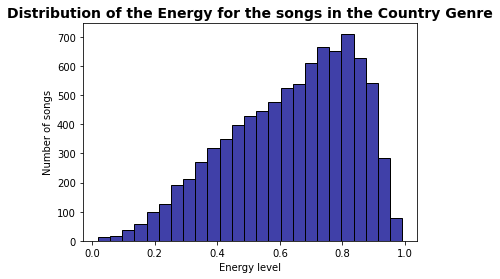

In [ ]:
# Your code here :
mask_country = df_music['genre'] == 'Country'

ax1 = sns.histplot(data = df_music[mask_country]
             , x = 'energy'
             , color ='darkblue'
             , bins = 25
             )
ax1.set_title('Distribution of the Energy for the songs in the Country Genre', weight = 'bold', fontsize = 14)
ax1.set_xlabel('Energy level')
ax1.set_ylabel("Number of songs")

plt.show()

## Interactive chart
With plotly express, draw an interactive **histogram on energy**. 
- You'll add an animation frame on `genre`.
- Please be sure that the vertical scale is appropriate. Histograms should not "stick out" vertically, regardless of the `genre`.
- Don't forget the title.

In [ ]:
# Your code here :

import plotly.express as px

fig = px.histogram(df_music
                , x= "energy"
                , animation_frame = 'genre'
                 , histnorm='percent'
                 , nbins = 50)

fig.update_layout(title = 'Distribution of the Energy'
                  , title_x = 0.5
                  )
fig.update_xaxes(title = 'Energy level', 
                 range=[0, 1]
                 )
fig.update_yaxes(title = ' Number of songs %'
                , range=[0, 15]
                 )

fig.show()

Output hidden; open in https://colab.research.google.com to view.

# Machine Learning : Classification

## OPERA + REGGAETON

Train a classification model that predicts the genre between Opera and Reggaeton of a track with wichever columns you want. You can try different algorithms.

Try to get the best accuracy score on your test set!!! (without overfitting)

Please display a confusion matrix as well.

In [100]:
# Your code here:
df_opera_reggaeton = df_music.loc[df_music["genre"].isin(["Opera", "Reggaeton"])]
df_opera_reggaeton

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,nb_words
57582,Opera,Charles Gounod,Ave Maria,2kyEgPaAW8wdpvevPnkf0Z,62,0.9930,0.1320,163267,0.0195,0.888000,C,0.0569,-29.760,Major,0.0445,81.616,3/4,0.1400,9.0
57583,Opera,Richard Wagner,Tannhäuser: Overture,1U1i1HBJ5H8DY5J4fO8ySg,58,0.8310,0.0843,853827,0.1820,0.926000,E,0.1970,-15.880,Major,0.0356,73.750,4/4,0.0604,20.0
57584,Opera,Giacomo Puccini,"""Nessun dorma!""",74WjYdm3Lvbwnds4thYPUU,63,0.9610,0.1710,180933,0.3080,0.005460,D,0.3190,-12.383,Major,0.0456,171.798,5/4,0.0889,15.0
57585,Opera,Gioachino Rossini,Semiramide: Overture (Live),2wG5UNal67Vkyjsdm3Ahat,2,0.8960,0.2590,746600,0.1980,0.679000,A,0.6890,-19.621,Major,0.0658,158.284,4/4,0.1590,27.0
57586,Opera,Gioachino Rossini,Overture (Sinfonia),1chTrqszWQEOP4RsNuOZf7,52,0.9110,0.3390,425000,0.1400,0.678000,E,0.1570,-20.598,Major,0.0470,95.975,4/4,0.2960,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166052,Reggaeton,Juhn,Burberry,6X7OHq7Fjdkl8jgJ7s2SsE,21,0.0200,0.7880,220961,0.8430,0.000000,G,0.1130,-5.417,Major,0.2410,135.874,4/4,0.4000,8.0
166053,Reggaeton,Musicologo Y Menes,Adicta (feat. Nicky Jam),2SNvQUgGOz7TtvTGbWUd1Z,24,0.0200,0.7730,181985,0.9200,0.000000,F#,0.1190,-4.117,Minor,0.0345,102.006,4/4,0.7590,24.0
166054,Reggaeton,Alex Kyza,Quien Te Dijo (REMIX) (feat. De La Ghetto),2SybcKL6xs1KizvciGmlwG,17,0.0158,0.8310,295187,0.7260,0.000011,C#,0.0823,-5.327,Minor,0.0380,96.998,4/4,0.4000,42.0
166055,Reggaeton,N'Klabe,Bailala Como Quieras,5morCKZwjNzpByAkdHyBQB,21,0.4450,0.7990,228573,0.8560,0.000007,A#,0.1690,-3.715,Major,0.1460,99.090,4/4,0.9430,20.0


### Preparing the data

In [101]:
# Selecting the columns for our model

X = df_opera_reggaeton.drop(['genre', 'track_name', 'track_id'], axis = 1)
y = df_opera_reggaeton['genre']
X

,artist_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,nb_words
57582,Charles Gounod,62,0.9930,0.1320,163267,0.0195,0.888000,C,0.0569,-29.760,Major,0.0445,81.616,3/4,0.1400,9.0
57583,Richard Wagner,58,0.8310,0.0843,853827,0.1820,0.926000,E,0.1970,-15.880,Major,0.0356,73.750,4/4,0.0604,20.0
57584,Giacomo Puccini,63,0.9610,0.1710,180933,0.3080,0.005460,D,0.3190,-12.383,Major,0.0456,171.798,5/4,0.0889,15.0
57585,Gioachino Rossini,2,0.8960,0.2590,746600,0.1980,0.679000,A,0.6890,-19.621,Major,0.0658,158.284,4/4,0.1590,27.0
57586,Gioachino Rossini,52,0.9110,0.3390,425000,0.1400,0.678000,E,0.1570,-20.598,Major,0.0470,95.975,4/4,0.2960,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166052,Juhn,21,0.0200,0.7880,220961,0.8430,0.000000,G,0.1130,-5.417,Major,0.2410,135.874,4/4,0.4000,8.0
166053,Musicologo Y Menes,24,0.0200,0.7730,181985,0.9200,0.000000,F#,0.1190,-4.117,Minor,0.0345,102.006,4/4,0.7590,24.0
166054,Alex Kyza,17,0.0158,0.8310,295187,0.7260,0.000011,C#,0.0823,-5.327,Minor,0.0380,96.998,4/4,0.4000,42.0
166055,N'Klabe,21,0.4450,0.7990,228573,0.8560,0.000007,A#,0.1690,-3.715,Major,0.1460,99.090,4/4,0.9430,20.0


In [102]:
# Factorization of some categorical columns

X['mode_fac'] = X['mode'].factorize()[0]

X['time_sign_fac'] = X['time_signature'].factorize()[0]

X['key_fac'] = X['key'].factorize()[0]

In [103]:
X['artist_name_fac'] = X['artist_name'].factorize()[0] #Plutot get_dummies / a revoir

In [104]:
# creation de df pour conserver le lien label / factorisation :
df_mode = X[['mode_fac', 'mode']]
df_time = X[['time_sign_fac', 'time_signature']]
df_key = X[['key_fac', 'key']]
df_artist_name = X[['artist_name_fac','artist_name']]

In [105]:
# dropping unwanted columns

X.drop(['mode','key','time_signature', 'artist_name'], axis = 1 , inplace = True)

In [106]:
X.head()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,nb_words,mode_fac,time_sign_fac,key_fac,artist_name_fac
57582,62,0.993,0.1320,163267,0.0195,0.88800,0.0569,-29.760,0.0445,81.616,0.1400,9.0,0,0,0,0
57583,58,0.831,0.0843,853827,0.1820,0.92600,0.1970,-15.880,0.0356,73.750,0.0604,20.0,0,1,1,1
57584,63,0.961,0.1710,180933,0.3080,0.00546,0.3190,-12.383,0.0456,171.798,0.0889,15.0,0,2,2,2
57585,2,0.896,0.2590,746600,0.1980,0.67900,0.6890,-19.621,0.0658,158.284,0.1590,27.0,0,1,3,3
57586,52,0.911,0.3390,425000,0.1400,0.67800,0.1570,-20.598,0.0470,95.975,0.2960,19.0,0,1,1,3


### PREPARING THE DATASET FOR ML and CHOICE OF THE PREDICTION MODEL

In [107]:
from sklearn.model_selection import train_test_split

In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=36, train_size = 0.75)

# Note: utiliser stratify pour la classification
print("The length of the initial dataset is :", len(X))
print("The length of the train dataset is   :", len(X_train))
print("The length of the test dataset is    :", len(X_test))

The length of the initial dataset is : 17207
The length of the train dataset is   : 12905
The length of the test dataset is    : 4302


### Using KNN Classifier to predict in which category will fall a song....

In [109]:
from sklearn.neighbors import KNeighborsClassifier

genre_model = KNeighborsClassifier()
genre_model.fit(X_train, y_train)
KNeighborsClassifier(...)

print('The accuracy score of our training dataset is of ', round(genre_model.score(X_train, y_train),4))

The accuracy score of our training dataset is of  0.9716


### Calculating the accuracy score on our test set

In [110]:
from sklearn.metrics import accuracy_score

print('The accuracy score of our test dataset is of ', round(accuracy_score(y_test, genre_model.predict(X_test)),4))


The accuracy score of our test dataset is of  0.9612


In [111]:
## The model is pretty good with hardly any overfitting.

## RAP + HIP HOP

Now train with the same parameters on these 2 genres: Rap and Hip-Hop.
You should have lower score than previously, why?

In [112]:
# Your code here

X.head()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,nb_words,mode_fac,time_sign_fac,key_fac,artist_name_fac
57582,62,0.993,0.1320,163267,0.0195,0.88800,0.0569,-29.760,0.0445,81.616,0.1400,9.0,0,0,0,0
57583,58,0.831,0.0843,853827,0.1820,0.92600,0.1970,-15.880,0.0356,73.750,0.0604,20.0,0,1,1,1
57584,63,0.961,0.1710,180933,0.3080,0.00546,0.3190,-12.383,0.0456,171.798,0.0889,15.0,0,2,2,2
57585,2,0.896,0.2590,746600,0.1980,0.67900,0.6890,-19.621,0.0658,158.284,0.1590,27.0,0,1,3,3
57586,52,0.911,0.3390,425000,0.1400,0.67800,0.1570,-20.598,0.0470,95.975,0.2960,19.0,0,1,1,3


In [113]:
# Your code here:
df_rap_hihop = df_music.loc[df_music["genre"].isin(["Rap", "Hip-Hop"])]
df_rap_hihop

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,nb_words
66607,Hip-Hop,J. Cole,MIDDLE CHILD,2JvzF1RMd7lE3KmFlsyZD8,96,0.14900,0.837,213594,0.364,0.000000,G#,0.2710,-11.713,Major,0.2760,123.984,4/4,0.463,12.0
66608,Hip-Hop,Meek Mill,Going Bad (feat. Drake),2IRZnDFmlqMuOrYOLnZZyc,95,0.25900,0.889,180522,0.496,0.000000,E,0.2520,-6.365,Minor,0.0905,86.003,4/4,0.544,23.0
66609,Hip-Hop,21 Savage,a lot,2t8yVaLvJ0RenpXUIAC52d,93,0.03950,0.837,288624,0.636,0.001250,C#,0.3420,-7.643,Major,0.0860,145.972,4/4,0.274,5.0
66610,Hip-Hop,Rich The Kid,Splashin,79OEIr4J4FHV0O3KrhaXRb,88,0.00195,0.942,177806,0.383,0.000000,A#,0.0922,-8.099,Major,0.5650,100.021,4/4,0.380,8.0
66611,Hip-Hop,Sheck Wes,Mo Bamba,1xzBco0xcoJEDXktl7Jxrr,92,0.19400,0.729,183907,0.625,0.009860,E,0.2480,-5.266,Major,0.0315,146.034,4/4,0.261,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122392,Rap,Juicy J,On & On (feat. Tory Lanez & Belly),7DWIbNQklCxk329kZpW6so,51,0.04790,0.736,225613,0.581,0.000000,A,0.1670,-7.700,Minor,0.0697,126.006,4/4,0.480,34.0
122393,Rap,Eminem,Untouchable,6IvespQWGW4USXwexlVKDm,58,0.08030,0.554,370133,0.887,0.000000,G,0.1500,-3.367,Major,0.5030,172.233,4/4,0.648,11.0
122394,Rap,Lil Baby,Eat Or Starve,5v0XqJN4DE6kVDPfsetdKR,49,0.10700,0.738,180293,0.515,0.000000,C,0.0889,-10.120,Major,0.0984,75.040,4/4,0.647,13.0
122395,Rap,Future,Outta Time,0AkKwgg6rD4p7EpDlNpSz2,51,0.00597,0.750,168607,0.546,0.000032,F#,0.3770,-6.951,Minor,0.3840,75.443,4/4,0.438,10.0


In [114]:
# Selecting the columns for our model

X2 = df_rap_hihop.drop(['genre', 'track_name', 'track_id'], axis = 1)
y2 = df_rap_hihop['genre']
X2

,artist_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,nb_words
66607,J. Cole,96,0.14900,0.837,213594,0.364,0.000000,G#,0.2710,-11.713,Major,0.2760,123.984,4/4,0.463,12.0
66608,Meek Mill,95,0.25900,0.889,180522,0.496,0.000000,E,0.2520,-6.365,Minor,0.0905,86.003,4/4,0.544,23.0
66609,21 Savage,93,0.03950,0.837,288624,0.636,0.001250,C#,0.3420,-7.643,Major,0.0860,145.972,4/4,0.274,5.0
66610,Rich The Kid,88,0.00195,0.942,177806,0.383,0.000000,A#,0.0922,-8.099,Major,0.5650,100.021,4/4,0.380,8.0
66611,Sheck Wes,92,0.19400,0.729,183907,0.625,0.009860,E,0.2480,-5.266,Major,0.0315,146.034,4/4,0.261,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122392,Juicy J,51,0.04790,0.736,225613,0.581,0.000000,A,0.1670,-7.700,Minor,0.0697,126.006,4/4,0.480,34.0
122393,Eminem,58,0.08030,0.554,370133,0.887,0.000000,G,0.1500,-3.367,Major,0.5030,172.233,4/4,0.648,11.0
122394,Lil Baby,49,0.10700,0.738,180293,0.515,0.000000,C,0.0889,-10.120,Major,0.0984,75.040,4/4,0.647,13.0
122395,Future,51,0.00597,0.750,168607,0.546,0.000032,F#,0.3770,-6.951,Minor,0.3840,75.443,4/4,0.438,10.0


### Preparing the data

In [115]:
# Factorization of some categorical columns

X2['mode_fac'] = X2['mode'].factorize()[0]

X2['time_sign_fac'] = X2['time_signature'].factorize()[0]

X2['key_fac'] = X2['key'].factorize()[0]

In [116]:
X2['artist_name_fac'] = X2['artist_name'].factorize()[0]

In [117]:
# creation de df pour conserver le lien label / factorisation :
df_mode = X2[['mode_fac', 'mode']]
df_time = X2[['time_sign_fac', 'time_signature']]
df_key = X2[['key_fac', 'key']]
df_artist_name = X2[['artist_name_fac','artist_name']]

In [118]:
# dropping unwanted columns

X2.drop(['mode','key','time_signature', 'artist_name'], axis = 1 , inplace = True)

In [119]:
X2.head()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,nb_words,mode_fac,time_sign_fac,key_fac,artist_name_fac
66607,96,0.14900,0.837,213594,0.364,0.00000,0.2710,-11.713,0.2760,123.984,0.463,12.0,0,0,0,0
66608,95,0.25900,0.889,180522,0.496,0.00000,0.2520,-6.365,0.0905,86.003,0.544,23.0,1,0,1,1
66609,93,0.03950,0.837,288624,0.636,0.00125,0.3420,-7.643,0.0860,145.972,0.274,5.0,0,0,2,2
66610,88,0.00195,0.942,177806,0.383,0.00000,0.0922,-8.099,0.5650,100.021,0.380,8.0,0,0,3,3
66611,92,0.19400,0.729,183907,0.625,0.00986,0.2480,-5.266,0.0315,146.034,0.261,8.0,0,0,1,4


### PREPARING THE DATASET FOR ML and CHOICE OF THE PREDICTION MODEL

In [120]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, random_state=36, train_size = 0.75)

# Note: utiliser stratify pour la classification
print("The length of the initial dataset is :", len(X2))
print("The length of the train dataset is   :", len(X2_train))
print("The length of the test dataset is    :", len(X2_test))

The length of the initial dataset is : 18527
The length of the train dataset is   : 13895
The length of the test dataset is    : 4632


### Using KNN Classifier to predict in which category will fall a song....

In [121]:
rap_hiphop_model = KNeighborsClassifier()
rap_hiphop_model.fit(X2_train, y2_train)
KNeighborsClassifier(...)

print('The accuracy score of our training dataset is of ', round(rap_hiphop_model.score(X2_train, y2_train),6))

The accuracy score of our training dataset is of  0.667362


### Calculating the accuracy score on our test set

In [122]:
from sklearn.metrics import accuracy_score

print('The accuracy score of our test dataset is of ', round(accuracy_score(y2_test, rap_hiphop_model.predict(X2_test)),4))


The accuracy score of our test dataset is of  0.44


In [123]:
## The accuracy model for our training is rather low and the score of our test shows our model is overfitted.

# The score is lower with those 2 genres than with Opera and Reggaeton.
# This is quite normal as rap and hip hop are rather similar genres. 
# This is not the case for Opera and Reggaeton very different so pretty easy to differentiate.


# Machine Learning : Regression (bonus question)
In this part we will try to predict the **"loudness"** of a track. 

## Univariate regression
First we will train an **univariate linear regression** model.

Find the most correlated column with **loudness**.

In [196]:
##Fait apres le temps

## Import librairies
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [197]:
# energy is the most correlated column (from heatmap)

In [198]:
X_loud_nrj = df_music[['energy']]
y_loud_nrj = df_music['loudness']

Split your dataset into a train and test set (using 80% as train and 20% as test). 

Use a `random_state` of **1** (for reproductivity sake).

In [199]:
X_train_loud_nrj, X_test_loud_nrj, y_train_loud_nrj, y_test_loud_nrj = train_test_split(X_loud_nrj, y_loud_nrj, random_state= 1 , train_size = 0.8)

# Note: utiliser stratify pour la classification
print("The length of the initial dataset is :", len(X_loud_nrj))
print("The length of the train dataset is   :", len(X_train_loud_nrj))
print("The length of the test dataset is    :", len(X_test_loud_nrj))

The length of the initial dataset is : 232725
The length of the train dataset is   : 186180
The length of the test dataset is    : 46545


Now train your model on the train set.

In [200]:
# Train our model - FIT
model_music = LinearRegression()\
    .fit(X_train_loud_nrj, y_train_loud_nrj)

#lr = LinearRegression()
#model_lr = lr.fit(X_train, y_train)

And evaluate it on the test set. If you did everything right your score should be `0.6689508695872618`.

In [201]:
# Evaluation du modèle et Comparison train & test scores - R²
print("R² score for the Train dataset :", round(model_music.score(X_train_loud_nrj, y_train_loud_nrj),5))
print("R² score for the Test dataset :", round(model_music.score(X_test_loud_nrj, y_test_loud_nrj), 5))

R² score for the Train dataset : 0.66526
R² score for the Test dataset : 0.66895


Visualize your data with a scatter plot (different colors for the train and the test set).

Add a lineplot of the regression.

You should get something like this. But of course, your graphic will have nicer colors, and a title!

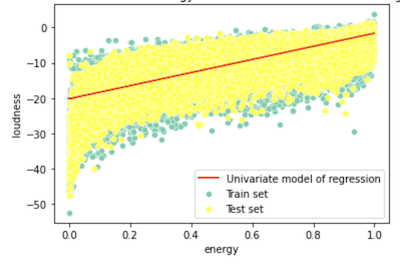

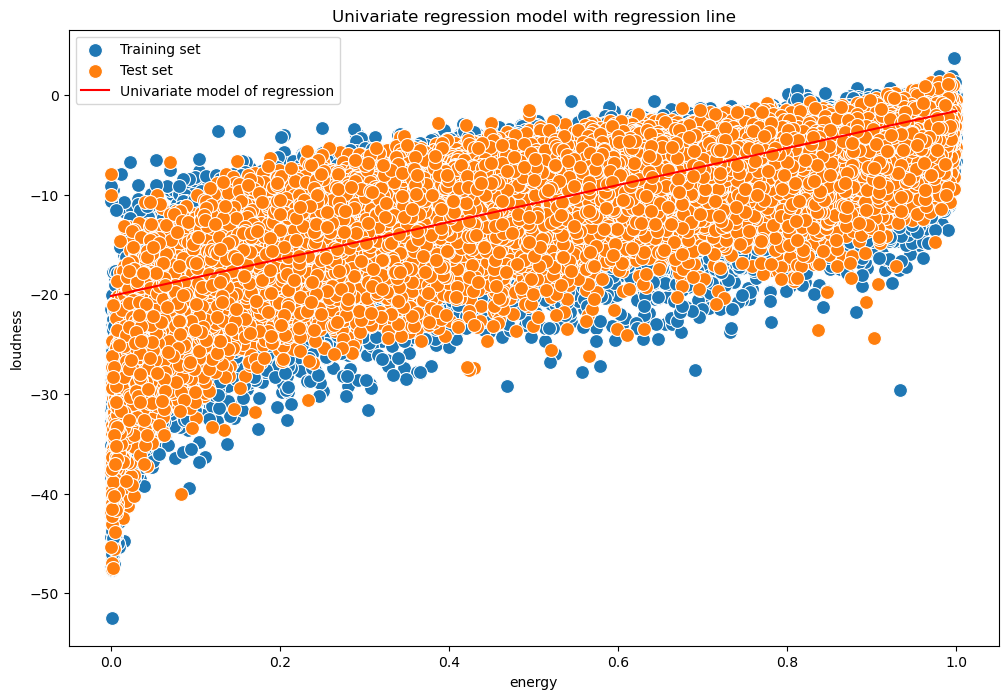

In [202]:
plt.figure(figsize=(12, 8))

# Scatter plot for training set
sns.scatterplot(x = X_train_loud_nrj['energy']
                , y = df_music['loudness']
                , s=100
                , label = 'Training set')

# Scatter plot for test set
sns.scatterplot(x = X_test_loud_nrj['energy']
                , y = df_music['loudness']
                , s=100
                , label = 'Test set')


# Regression line
x_line = np.linspace(0, 1, 100)
y_line = model_music.coef_[0] * x_line + model_music.intercept_
sns.lineplot(x=x_line
             , y=y_line
             , color='red'
             , label='Univariate model of regression')

plt.legend()
plt.title('Univariate regression model with regression line')
plt.show()

Print the equation of the regression.

In [203]:
model_music.coef_

array([18.56775242])

In [204]:
model_music.intercept_

-20.17158065753097

In [205]:
# Replace a and b by the coefficients

a = model_music.coef_
b = model_music.intercept_
print('regression equation = ',a[0],"* x +", b)


regression equation =  18.567752424361153 * x + -20.17158065753097


Please predict the "**loudness**" for a an energy of 0.62

In [206]:
x = 0.62
reg_eq_nrj =  a * x + b

print(reg_eq_nrj)

[-8.65957415]


## Multivariate regression

Now you will predict the **loudness** of a track with all the others numericals columns. 

You will do all the needed steps and keep a `random_state` of 1.

Your test score should be : `0.7650705916016727`. Is there overfitting?

In [207]:
##Fait apres le temps

## Import librairies
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [208]:
columns =["acousticness", "danceability", "duration_ms", "energy",
          "instrumentalness", "liveness", "popularity", "speechiness", "tempo", "valence"]

In [209]:
X_loud = df_music[columns]
y_loud = df_music['loudness']
X_loud.head()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,popularity,speechiness,tempo,valence
0,0.611,0.389,99373,0.910,0.000,0.3460,0,0.0525,166.969,0.814
1,0.246,0.590,137373,0.737,0.000,0.1510,1,0.0868,174.003,0.816
2,0.952,0.663,170267,0.131,0.000,0.1030,3,0.0362,99.488,0.368
3,0.703,0.240,152427,0.326,0.000,0.0985,0,0.0395,171.758,0.227
4,0.950,0.331,82625,0.225,0.123,0.2020,4,0.0456,140.576,0.390


Split your dataset into a train and test set (using 80% as train and 20% as test). 

Use a `random_state` of **1** (for reproductivity sake).

In [210]:
X_train_loud, X_test_loud, y_train_loud, y_test_loud = train_test_split(X_loud, y_loud, random_state= 1 , train_size = 0.8)

# Note: utiliser stratify pour la classification
print("The length of the initial dataset is :", len(X_loud))
print("The length of the train dataset is   :", len(X_train_loud))
print("The length of the test dataset is    :", len(X_test_loud))

The length of the initial dataset is : 232725
The length of the train dataset is   : 186180
The length of the test dataset is    : 46545


Now train your model on the train set.

In [211]:
# Train our model - FIT
model_music2 = LinearRegression().fit(X_train_loud, y_train_loud)

In [212]:
# Evaluation du modèle et Comparison train & test scores - R²
print("R² score for the Train dataset :", round(model_music2.score(X_train_loud, y_train_loud),5))
print("R² score for the Test dataset :", round(model_music2.score(X_test_loud, y_test_loud), 5))

R² score for the Train dataset : 0.76543
R² score for the Test dataset : 0.76507


In [213]:
# Modèle convenable et il n'y a pas d'overfitting dans ce modele multivarié

In [214]:
model_music2.coef_

array([-5.25420345e-01,  5.26533434e+00, -8.93601877e-08,  1.57667490e+01,
       -4.05772148e+00, -8.07989767e-01,  2.35999114e-02, -4.10796100e+00,
        5.51375388e-03, -1.60681007e+00])

In [215]:
model_music2.intercept_

-20.89277097696086

In [216]:
for i,j in zip(X_loud.columns, model_music.coef_):
  print(i,j)

acousticness 18.567752424361153


# Comparison between the top 1% popularity and the total dataset (bonus question)
Find a way to compare songs with highest popularity and the others. Something like this example, but you could be creative.

Here we've compared the frequencies by genre (35% of top-songs are "pop", versus 4% of pop songs in the total dataset)




![comparison](https://raw.githubusercontent.com/murpi/wilddata/master/checkpoint2_comparison.png)

Work on our main DF

In [3]:
# Our dataset (reminder) :

df_music.sort_values('popularity', ascending = False).head()


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
9027,Dance,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.5780,0.725,178640,0.321,0.000000,C#,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319
107804,Pop,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.5780,0.725,178640,0.321,0.000000,C#,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319
86951,Rap,Post Malone,Wow.,6MWtB6iiXyIwun0YzU6DFP,99,0.1630,0.833,149520,0.539,0.000002,B,0.1010,-7.399,Minor,0.1780,99.947,4/4,0.385
107803,Pop,Post Malone,Wow.,6MWtB6iiXyIwun0YzU6DFP,99,0.1630,0.833,149520,0.539,0.000002,B,0.1010,-7.399,Minor,0.1780,99.947,4/4,0.385
107802,Pop,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,0.0421,0.726,190440,0.554,0.000000,F,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.335


In [4]:
len(df_music)

232725

In [5]:
df_music.columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')

### Replicating above chart

In [6]:
# our most popular songs (top 1%): 
one_percent = len(df_music)//100

# Extracting the most popular song from the dataset
most_pop = df_music.sort_values('popularity', ascending = False).nlargest(one_percent, 'popularity')

# Get the threshold value for the top 1%
threshold = most_pop['popularity'].min()

# Create the 'top_1%' column as a boolean mask
df_music['top_1%'] = df_music['popularity'] >= threshold

In [7]:
df_music.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,top_1%
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814,False
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816,False
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368,False
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227,False
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390,False


In [8]:
# creating a specififc dataset for those 1%
most_popular = df_music[df_music['top_1%'] == True]

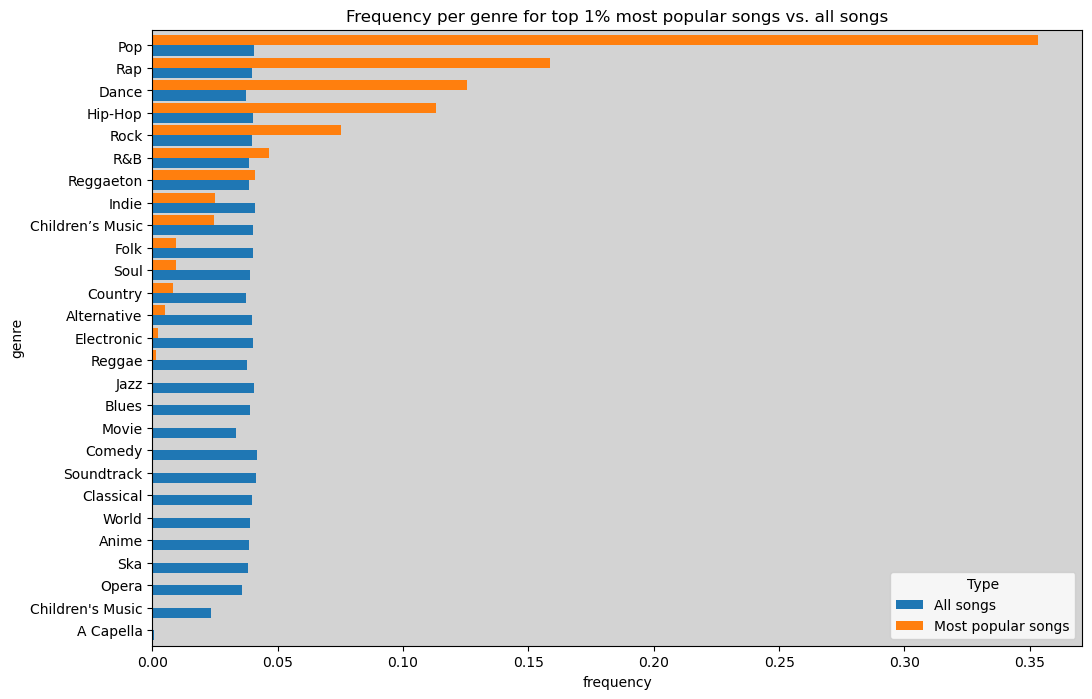

In [ ]:
# Plotting this dataset above vs the full dataset based on frequency
# Te normalization helps to compare the frequency of genres in both datasets
all_songs =  df_music['genre'].value_counts(normalize= True).sort_values(ascending=False)
most_pop =  most_popular['genre'].value_counts(normalize= True).sort_values(ascending=False)


# Combining those 2 series into one dataframe so we can plot them together
freq_df = pd.DataFrame({ 
                        "All songs": all_songs,
                        "Most popular songs": most_pop})\
                        .fillna(0)\
                        .sort_values(by=[ "Most popular songs","All songs"])

# Align both Series on the same genres
#genres = all_songs.index
#most_pop = most_pop.reindex(genres, fill_value=0)

# Plot
ax = freq_df.plot.barh(figsize=(12,8), width= 0.9)

ax.grid(False)
ax.set_facecolor("lightgrey")

plt.title('Frequency per genre for top 1% most popular songs vs. all songs')
plt.xlabel('frequency')
plt.legend(title="Type")
plt.show()

### Being more creative - Studying Valence, Instrumentalness, Danceability, Tempo, Energy
We are gonna work on 4 specific metrics to check how those top 1% differ from the rest

In [294]:
columns = ['valence','instrumentalness', 'danceability', 'tempo', 'energy']
X = df_music[columns]

In [295]:
X.head()

,valence,instrumentalness,danceability,tempo,energy
0,0.814,0.000,0.389,166.969,0.910
1,0.816,0.000,0.590,174.003,0.737
2,0.368,0.000,0.663,99.488,0.131
3,0.227,0.000,0.240,171.758,0.326
4,0.390,0.123,0.331,140.576,0.225


In [296]:
# standardize our data frame for easier comp

X_std = (X - X.min()) / (X.max() - X.min())

In [297]:
X_std.mean().to_frame().reset_index()

,index,0
0,valence,0.454917
1,instrumentalness,0.148450
2,danceability,0.533703
3,tempo,0.410719
4,energy,0.571520


Work on our top 1%

In [298]:
X_pop = df_music[columns][df_music['top_1%']==True]

In [299]:
X_pop.head()

,valence,instrumentalness,danceability,tempo,energy
671,0.316,0.000275,0.552,167.788,0.650
672,0.284,0.005980,0.515,88.964,0.479
677,0.780,0.000000,0.731,104.034,0.861
679,0.772,0.002330,0.818,138.559,0.705
682,0.458,0.000105,0.559,84.581,0.345


In [306]:
# Normalize our most pop data frame for easier comp 

X_std_pop = (X_pop - X_pop.min()) / (X_pop.max() - X_pop.min())

In [280]:
##MinMax Scaller depuis sckitlearn

In [308]:
X_std_pop.mean().to_frame().reset_index()

,index,0
0,valence,0.484520
1,instrumentalness,0.005851
2,danceability,0.626551
3,tempo,0.459722
4,energy,0.630875


#### GRAPH COMPARISON - using PLOTLY

In [314]:
import plotly.graph_objects as go

In [315]:
categories = ['Valence','Instrumentalness', 'Danceability', 'Tempo', 'Energy']

In [316]:
fig = go.Figure()

fig.add_trace(
                go.Scatterpolar(
                            r =   X_std.mean().to_list()  
                            , theta = categories
                            , fill ='toself'
                            , name = 'Spotify DB'
                            , fillcolor= 'yellow'
                            , showlegend=True, opacity=0.5
                            , line = dict(color = 'darkblue', width = 3)
                )
                )

fig.add_trace(
                go.Scatterpolar(
                            r =   X_std_pop.mean().to_list()  
                            , theta = categories
                           , fill ='toself'
                            , name = 'Most popular'
                            , fillcolor = 'darkred'
                            , showlegend = True, opacity=0.6
                            , line = dict(color='red', width = 3)
                            )
            )


fig.update_layout(
            polar = dict(radialaxis=dict(visible=True, range=[0, 0.7]))
            , autosize=False,
            width = 500,
            height = 500,
            margin = dict( pad = 1)
)

fig.show()